## Building a Rainfall Prediction Classifier  

                      ⛅☔

### Objectives   
**.** Explore and perform feature engineering on a real-world data set  
**.** Build a classifier pipeline and optimize it using grid search cross validation  
**.** Evaluate your model by interpreting various performance metrics and visualizations  
**.** Implement a different classifier by updating your pipeline   
**.** Use an appropriate set of parameters to search over in each case

### About dataset  
The original source of the data is Australian Government's Bureau of Meteorology and the latest data can be gathered from http://www.bom.gov.au/climate/dwo/.

The dataset you'll use in this project was downloaded from Kaggle at https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package/   
Column definitions were gathered from http://www.bom.gov.au/climate/dwo/IDCJDW0000.shtml   

The dataset contains observations of weather metrics for each day from 2008 to 2017, and includes the following fields:

####  Required libraries

In [1]:
#!pip install numpy
#!pip install pandas
#!pip install matplotlib
#!pip install scikit-learn
#!pip install seaborn

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

#### Load dataset

In [3]:
df = pd.read_csv('weatherAUS.csv')

In [4]:
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [5]:
df.count()

Date             145460
Location         145460
MinTemp          143975
MaxTemp          144199
Rainfall         142199
Evaporation       82670
Sunshine          75625
WindGustDir      135134
WindGustSpeed    135197
WindDir9am       134894
WindDir3pm       141232
WindSpeed9am     143693
WindSpeed3pm     142398
Humidity9am      142806
Humidity3pm      140953
Pressure9am      130395
Pressure3pm      130432
Cloud9am          89572
Cloud3pm          86102
Temp9am          143693
Temp3pm          141851
RainToday        142199
RainTomorrow     142193
dtype: int64

Sunshine and cloud cover seem like important features, but they have a lot of missing values,  
far too many to impute their missing values.  
**Drop all rows with missing values**  
To try to keep things simple we'll drop rows with missing values and see what's left

In [6]:
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 56420 entries, 6049 to 142302
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           56420 non-null  object 
 1   Location       56420 non-null  object 
 2   MinTemp        56420 non-null  float64
 3   MaxTemp        56420 non-null  float64
 4   Rainfall       56420 non-null  float64
 5   Evaporation    56420 non-null  float64
 6   Sunshine       56420 non-null  float64
 7   WindGustDir    56420 non-null  object 
 8   WindGustSpeed  56420 non-null  float64
 9   WindDir9am     56420 non-null  object 
 10  WindDir3pm     56420 non-null  object 
 11  WindSpeed9am   56420 non-null  float64
 12  WindSpeed3pm   56420 non-null  float64
 13  Humidity9am    56420 non-null  float64
 14  Humidity3pm    56420 non-null  float64
 15  Pressure9am    56420 non-null  float64
 16  Pressure3pm    56420 non-null  float64
 17  Cloud9am       56420 non-null  float64
 18  Cl

Since we still have 56k observations left after dropping missing values, we may not need to impute any missing values.
Let's see how we do.

In [7]:
df.columns

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow'],
      dtype='object')

If we adjust our approach and aim to predict today’s rainfall using historical weather data up to and including yesterday, then  we can legitimately utilize all of the available features. This shift would be particularly useful for practical applications,  
such as deciding whether you will bike to work today.   

With this new target, we should update the names of the rain columns accordingly to avoid confusion.

In [8]:
#rename columns
df = df.rename(columns = {'RainToday': 'RainYesterday',
                        'RainTomorrow': 'RainToday'})

In [9]:
df.columns

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainYesterday', 'RainToday'],
      dtype='object')

### Location selection   
You could do some research to group cities in the Location column by distance, which I've done for you behind the scenes.  
I found that Watsonia is only 15 km from Melbourne, and the Melbourne Airport is only 18 km from Melbourne.   
Let's group these three locations together and use only their weather data to build our localized prediction model.   
Because there might still be some slight variations in the weather patterns we'll keep Location as a categorical variable.

In [10]:
df = df[df.Location.isin(['Melbourne','MelbourneAirport','Watsonia',])]
df. info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7557 entries, 64191 to 80997
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           7557 non-null   object 
 1   Location       7557 non-null   object 
 2   MinTemp        7557 non-null   float64
 3   MaxTemp        7557 non-null   float64
 4   Rainfall       7557 non-null   float64
 5   Evaporation    7557 non-null   float64
 6   Sunshine       7557 non-null   float64
 7   WindGustDir    7557 non-null   object 
 8   WindGustSpeed  7557 non-null   float64
 9   WindDir9am     7557 non-null   object 
 10  WindDir3pm     7557 non-null   object 
 11  WindSpeed9am   7557 non-null   float64
 12  WindSpeed3pm   7557 non-null   float64
 13  Humidity9am    7557 non-null   float64
 14  Humidity3pm    7557 non-null   float64
 15  Pressure9am    7557 non-null   float64
 16  Pressure3pm    7557 non-null   float64
 17  Cloud9am       7557 non-null   float64
 18  Clo

We still have 7557 records, which should be enough to build a reasonably good model.  
You could always gather more data if needed by partioning the data into similar locations or simplyby updating it from the  
source to include a larger time frame.   

## Extracting a seasonality feature  
Now consider the `Date` column. We expect the weather patterns to be seasonal, having different predictablitiy levels in winter  and summer for example.  
There may be some variation with `Year` as well, but we'll leave that out for now.  
Let's engineer a `Season` feature from `Date` and drop `Date` afterward, since it is most likely less informative than season.  
An easy way to do this is to define a function that assigns seasons to given months, then use that function to transform the  
`Date` column.

####  Create a function to map dates to seasons 

In [11]:
def date_to_season(date):
    month = date.month
    if (month == 12) or (month == 1) or (month == 2):
        return 'Summer'
    elif (month == 3) or (month == 4) or (month == 5):
        return 'Autumn'
    elif (month == 6) or (month == 7) or (month == 8):
        return 'Winter'
    elif (month == 9) or (month == 10) or (month == 11):
        return 'Spring'

In [12]:
# Convert the 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Apply the function to the 'Date' column
df['Season'] = df['Date'].apply(date_to_season)

# Drop the original Date column
df = df.drop(columns=['Date'])

# Display the updated DataFrame
df

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainYesterday,RainToday,Season
64191,MelbourneAirport,11.2,19.9,0.0,5.6,8.8,SW,69.0,W,SW,...,37.0,1005.1,1006.4,7.0,7.0,15.9,18.1,No,Yes,Summer
64192,MelbourneAirport,7.8,17.8,1.2,7.2,12.9,SSE,56.0,SW,SSE,...,43.0,1018.0,1019.3,6.0,7.0,12.5,15.8,Yes,No,Summer
64193,MelbourneAirport,6.3,21.1,0.0,6.2,10.5,SSE,31.0,E,S,...,35.0,1020.8,1017.6,1.0,7.0,13.4,19.6,No,No,Summer
64194,MelbourneAirport,8.1,29.2,0.0,6.4,12.5,SSE,35.0,NE,SSE,...,23.0,1016.2,1012.8,5.0,4.0,16.0,28.2,No,No,Summer
64195,MelbourneAirport,9.7,29.0,0.0,7.4,12.3,SE,33.0,SW,SSE,...,31.0,1011.9,1010.3,6.0,2.0,19.4,27.1,No,No,Summer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80992,Watsonia,3.6,14.5,0.0,2.4,8.8,NNE,41.0,ENE,NNE,...,66.0,1028.4,1025.0,1.0,7.0,5.2,13.8,No,No,Winter
80994,Watsonia,4.8,13.3,0.4,0.6,0.0,NNW,24.0,NE,NNE,...,63.0,1028.5,1025.1,7.0,7.0,5.6,12.4,No,No,Winter
80995,Watsonia,5.6,13.1,0.0,1.6,6.0,NNW,52.0,NE,N,...,67.0,1019.0,1014.0,1.0,7.0,8.8,11.6,No,Yes,Winter
80996,Watsonia,6.9,12.1,3.2,1.8,5.6,SSW,24.0,WNW,SW,...,61.0,1018.7,1017.3,2.0,7.0,7.9,11.0,Yes,No,Winter


Looks like we have a good set of features to work with.  

Let's go ahead and build our model.   

But wait, let's take a look at how well balanced our target is.

#### feature and target dataframes

In [13]:
# Separate features and target variable
X = df.drop(columns='RainToday')
y = df['RainToday']

In [14]:
#Display the count of each class
y.value_counts()

No     5766
Yes    1791
Name: RainToday, dtype: int64

#### Split data into training and test sets, ensuring target stratification

In [15]:
# Split data into training and test sets with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

Automatically detect numerical and categorical columns and assign them to separate numeric and categorical features

In [16]:
numeric_features = X_train.select_dtypes(include=['number']).columns.tolist()  
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

**Define separate transformers for both feature types and combine them into a single preprocessing transformer**

In [17]:
# Scale the numeric features
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])

# One-hot encode the categoricals 
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))])

**Combine the transformers into a single preprocessing column transformer**

In [18]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

**Create a pipeline by combining the preprocessing with a Random Forest classifier**

In [19]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

**Define a parameter grid to use in a cross validation grid search model optimizer**

In [20]:
param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5]
}

**Pipeline usage in crossvalidation**
Recall that the pipeline is repeatedly used within the crossvalidation by fitting on each internal training fold and predicting on its corresponding validation fold

Perform grid search cross-validation and fit the best model to the training data  
Select a cross-validation method, ensuring target stratification during validation

In [21]:
cv = StratifiedKFold(n_splits=5, shuffle=True)

**Instantiate and fit GridSearchCV to the pipeline**

In [22]:
grid_search = GridSearchCV(pipeline, param_grid, cv=cv, scoring='accuracy', verbose=2)  
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.6s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.4s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.5s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.4s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.3s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=100; total time=   0.8s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=100; total time=   0.9s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=100; total time=

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         ['MinTemp',
                                                                          'MaxTemp',
                                                                          'Rainfall',
                                                                          'Evaporation',
                                                                          'Sunshine',
                                                                          'WindGustSpeed',
                                                     

**Print the best parameters and best crossvalidation score**

In [23]:
print("\nBest parameters found: ", grid_search.best_params_)
print("Best cross-validation score: {:.2f}".format(grid_search.best_score_))


Best parameters found:  {'classifier__max_depth': None, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
Best cross-validation score: 0.85


**Display your model's estimated score**

In [24]:
test_score = grid_search.score(X_test, y_test)  
print("Test set score: {:.2f}".format(test_score))

Test set score: 0.84


So we have a reasonably accurate classifer, which is expected to correctly predict about 84% of the time whether it will rain today in the Melbourne area.  
But careful here. Let's take a deeper look at the results.  

**The best model is stored within the gridsearch object**.

model predictions from the grid search estimator on the unseen data

In [25]:
y_pred = grid_search.predict(X_test)

**Print the classification report**

In [26]:
# Print the classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

          No       0.86      0.95      0.90      1154
         Yes       0.76      0.50      0.60       358

    accuracy                           0.84      1512
   macro avg       0.81      0.72      0.75      1512
weighted avg       0.83      0.84      0.83      1512



**Plot the confusion matrix**

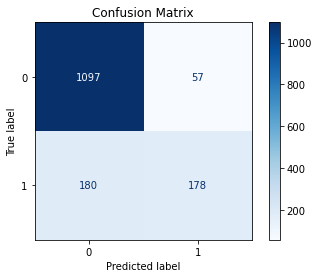

In [27]:
conf_matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

Let's consider wether the results indicate a good predictor of rainfall.

### Feature importances
Recall that to obtain the categorical feature importances, we have to work our way backward through the modelling pipeline to  
associate the feature importances with their original input variables, not the one-hot encoded ones. We don't need to do this  
for the numeric variables because we didn't modify their names in any way.  
Remember we went from categorical features to one-hot encoded features, using the 'cat' column transformer.  
Let's get all of the feature importances and associate them with their transformed features

**Extract the feature importances**

In [28]:
feature_importances = grid_search.best_estimator_['classifier'].feature_importances_

Now let's extract the feature importances and plot them as a bar graph.

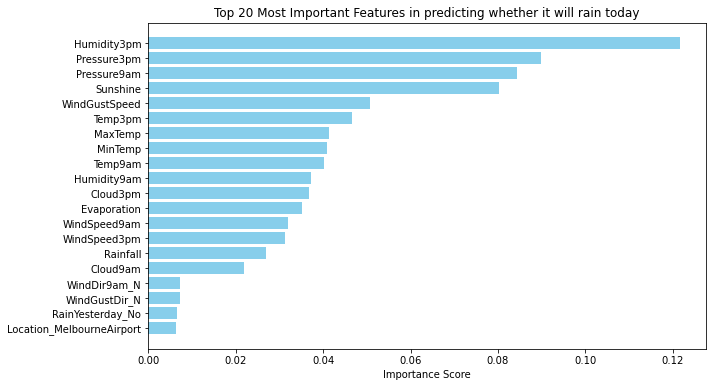

In [29]:
# Combine numeric and categorical feature names
feature_names = numeric_features + list(grid_search.best_estimator_['preprocessor']
                                        .named_transformers_['cat']
                                        .named_steps['onehot']
                                        .get_feature_names_out(categorical_features))

feature_importances = grid_search.best_estimator_['classifier'].feature_importances_

importance_df = pd.DataFrame({'Feature': feature_names,
                              'Importance': feature_importances
                             }).sort_values(by='Importance', ascending=False)

N = 20  # Change this number to display more or fewer features
top_features = importance_df.head(N)

# Plotting
plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'], top_features['Importance'], color='skyblue')
plt.gca().invert_yaxis()  # Invert y-axis to show the most important feature on top
plt.title(f'Top {N} Most Important Features in predicting whether it will rain today')
plt.xlabel('Importance Score')
plt.show()

**Try another model**

####  Update the pipeline and the parameter grid  
Let's update the pipeline and the parameter grid and train a Logistic Regression model and compare the performance of the two models. You'll need to replace the clasifier with LogisticRegression. We have supplied the parameter grid for you.

In [30]:
# 1. Replace RandomForestClassifier with LogisticRegression
pipeline.set_params(classifier=LogisticRegression(random_state=42))

# 2. Update the model's estimator to use the new pipeline
grid_search.estimator = pipeline

# 3. Define a new grid with Logistic Regression parameters
param_grid = {
    'classifier__solver' : ['liblinear'],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__class_weight' : [None, 'balanced']
}

# 4. Pass the new grid to the grid search object
grid_search.param_grid = param_grid

# 5. Fit the updated pipeline with LogisticRegression
grid_search.fit(X_train, y_train)

# 6. Make predictions using the updated, optimized grid search model
y_pred = grid_search.predict(X_test)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.2s
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.2s
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.1s
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.1s
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l2, classifier__solver=liblinear; total time=   0.1s
[CV] END classifier__class_weight=None, classifier__penalty=l2, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l2, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=No

###  Exploratory Data Analysis (EDA)   

#### Rainfal DIstribution by Season  

Let's visualize how rainfall (`RainToday`) is distributed across seasons to understand seasonal patterns.

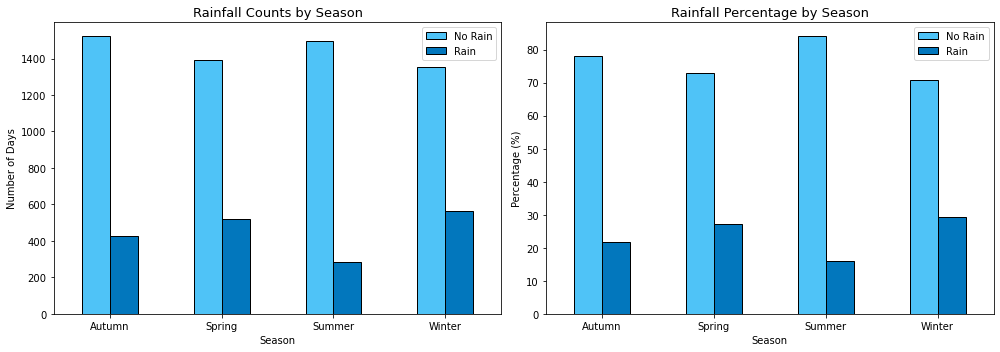

In [31]:
# Count rain vs no-rain per season
season_rain = df.groupby(['Season', 'RainToday']).size().unstack(fill_value=0)
season_rain_pct = season_rain.div(season_rain.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absolute counts
season_rain.plot(kind='bar', ax=axes[0], color=['#4fc3f7', '#0277bd'], edgecolor='black')
axes[0].set_title('Rainfall Counts by Season', fontsize=13)
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Number of Days')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(['No Rain', 'Rain'])

# Percentage
season_rain_pct.plot(kind='bar', ax=axes[1], color=['#4fc3f7', '#0277bd'], edgecolor='black')
axes[1].set_title('Rainfall Percentage by Season', fontsize=13)
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(['No Rain', 'Rain'])

plt.tight_layout()
plt.show()

#### Correlation Heatmap of Numeric Features
A heatmap helps us understand which numeric features are strongly correlated with each other and with the target.

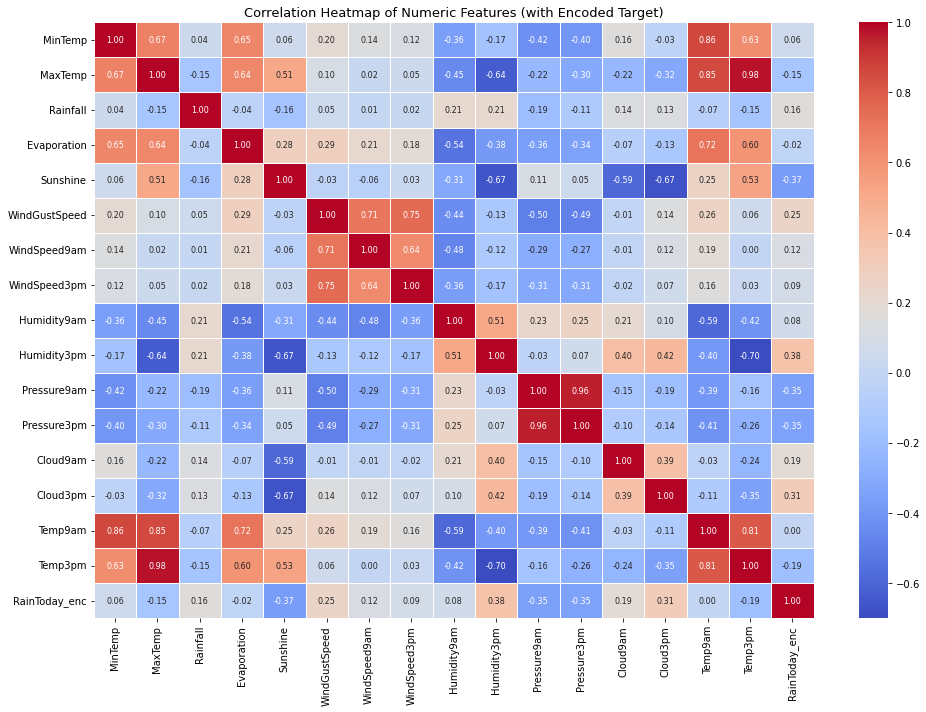

In [32]:
# Correlation Heatmap
plt.figure(figsize=(14, 10))
numeric_cols = df.select_dtypes(include='number').columns.tolist()

# Encode target for correlation
df_corr = df[numeric_cols].copy()
df_corr['RainToday_enc'] = (df['RainToday'] == 'Yes').astype(int)

corr_matrix = df_corr.corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={"size": 8})
plt.title('Correlation Heatmap of Numeric Features (with Encoded Target)', fontsize=13)
plt.tight_layout()
plt.show()

#### Key Feature Distributions: Rain vs No Rain
Boxplots for top numeric features split by whether it rained today.

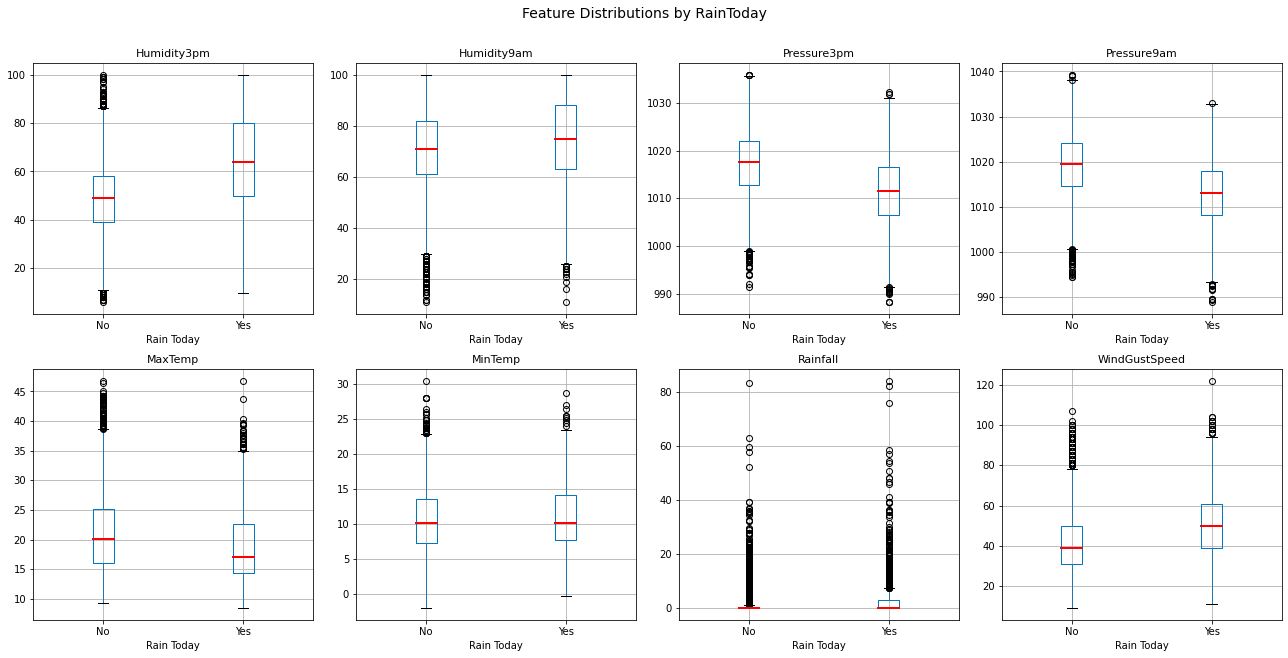

In [33]:
# Boxplots for top features vs RainToday
top_numeric = ['Humidity3pm', 'Humidity9am', 'Pressure3pm', 'Pressure9am',
               'MaxTemp', 'MinTemp', 'Rainfall', 'WindGustSpeed']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(top_numeric):
    if col in df.columns:
        df.boxplot(column=col, by='RainToday', ax=axes[i],
                   boxprops=dict(color='#0277bd'),
                   medianprops=dict(color='red', linewidth=2))
        axes[i].set_title(col, fontsize=11)
        axes[i].set_xlabel('Rain Today')
        axes[i].set_ylabel('')

plt.suptitle('Feature Distributions by RainToday', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


### Decision Tree Classifier   

Let's train a `third` model `Decision` `Tree` `Classifier` using the same `pipeline` structure and compare it with `Random` `Forest` and `Logistic` `Regression`.

In [34]:
from sklearn.tree import DecisionTreeClassifier

# Replace classifier with DecisionTreeClassifier
pipeline.set_params(classifier=DecisionTreeClassifier(random_state=42))

# Update estimator and param grid
grid_search.estimator = pipeline

param_grid_dt = {
    'classifier__max_depth': [5, 10, 20, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__class_weight': [None, 'balanced']
}

grid_search.param_grid = param_grid_dt

# Fit and predict
grid_search.fit(X_train, y_train)
y_pred_dt = grid_search.predict(X_test)

print("Best DT params:", grid_search.best_params_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END classifier__class_weight=None, classifier__max_depth=5, classifier__min_samples_split=2; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__max_depth=5, classifier__min_samples_split=2; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__max_depth=5, classifier__min_samples_split=2; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__max_depth=5, classifier__min_samples_split=2; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__max_depth=5, classifier__min_samples_split=2; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__max_depth=5, classifier__min_samples_split=5; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__max_depth=5, classifier__min_samples_split=5; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__max_depth=5, classifier__min_samples_split=5; total time=   0.0s
[C

[CV] END classifier__class_weight=balanced, classifier__max_depth=5, classifier__min_samples_split=10; total time=   0.0s
[CV] END classifier__class_weight=balanced, classifier__max_depth=5, classifier__min_samples_split=10; total time=   0.0s
[CV] END classifier__class_weight=balanced, classifier__max_depth=5, classifier__min_samples_split=10; total time=   0.0s
[CV] END classifier__class_weight=balanced, classifier__max_depth=5, classifier__min_samples_split=10; total time=   0.0s
[CV] END classifier__class_weight=balanced, classifier__max_depth=5, classifier__min_samples_split=10; total time=   0.0s
[CV] END classifier__class_weight=balanced, classifier__max_depth=10, classifier__min_samples_split=2; total time=   0.0s
[CV] END classifier__class_weight=balanced, classifier__max_depth=10, classifier__min_samples_split=2; total time=   0.0s
[CV] END classifier__class_weight=balanced, classifier__max_depth=10, classifier__min_samples_split=2; total time=   0.0s
[CV] END classifier__cla

In [35]:
print("Best DT params:", grid_search.best_params_)
print("\nClassification Report - Decision Tree:")
print(classification_report(y_test, y_pred_dt))

Best DT params: {'classifier__class_weight': None, 'classifier__max_depth': 5, 'classifier__min_samples_split': 2}

Classification Report - Decision Tree:
              precision    recall  f1-score   support

          No       0.86      0.91      0.88      1154
         Yes       0.63      0.52      0.57       358

    accuracy                           0.81      1512
   macro avg       0.74      0.71      0.72      1512
weighted avg       0.80      0.81      0.81      1512



####  Confusion matrix of Decision Tree

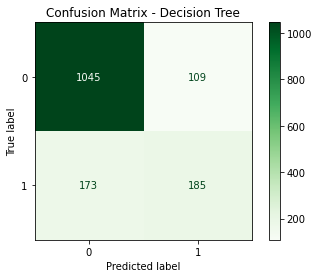

In [36]:
# Confusion matrix
conf_matrix_dt = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_dt)
disp.plot(cmap='Greens')
plt.title('Confusion Matrix - Decision Tree')
plt.show()

### ROC Curve Comparison   
The **ROC (Receiver Operating Characteristic)** curve plots the true positive rate vs. false positive rate at different thresholds. The **AUC (Area Under Curve)** score summarises model performance a perfect classifier scores 1.0.

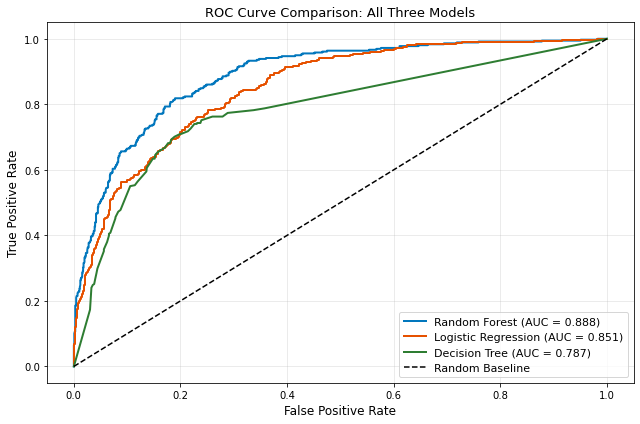

Random Forest AUC:       0.8884
Logistic Regression AUC: 0.8507
Decision Tree AUC:       0.7865


In [37]:
# ROC Curve Comparison for all three models
from sklearn.metrics import roc_curve, roc_auc_score

# We need probability outputs — retrain each best model to get predict_proba
# Random Forest
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=20,
                                           min_samples_split=2, random_state=42))
])
pipeline_rf.fit(X_train, y_train)
y_proba_rf = pipeline_rf.predict_proba(X_test)[:, 1]

# Logistic Regression
pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', penalty='l2',
                                       class_weight='balanced', random_state=42))
])
pipeline_lr.fit(X_train, y_train)
y_proba_lr = pipeline_lr.predict_proba(X_test)[:, 1]

# Decision Tree
pipeline_dt = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=10, min_samples_split=2,
                                           class_weight='balanced', random_state=42))
])
pipeline_dt.fit(X_train, y_train)
y_proba_dt = pipeline_dt.predict_proba(X_test)[:, 1]

# Encode target for roc_auc
y_test_enc = (y_test == 'Yes').astype(int)

fpr_rf, tpr_rf, _ = roc_curve(y_test_enc, y_proba_rf)
fpr_lr, tpr_lr, _ = roc_curve(y_test_enc, y_proba_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test_enc, y_proba_dt)

auc_rf = roc_auc_score(y_test_enc, y_proba_rf)
auc_lr = roc_auc_score(y_test_enc, y_proba_lr)
auc_dt = roc_auc_score(y_test_enc, y_proba_dt)

plt.figure(figsize=(9, 6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})', color='#0277bd', lw=2)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})', color='#e65100', lw=2)
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.3f})', color='#2e7d32', lw=2)
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Baseline')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison: All Three Models', fontsize=13)
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Random Forest AUC:       {auc_rf:.4f}")
print(f"Logistic Regression AUC: {auc_lr:.4f}")
print(f"Decision Tree AUC:       {auc_dt:.4f}")

###  Model Performance Summary Table  
Let's build a summary table comparing all three models across key metrics: `Accuracy`, `Precision`, `Recall`, `F1-Score`, and `AUC`.

This is a professional practice to clearly communicate model selection decisions.

In [38]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Predictions from each fitted pipeline
y_pred_rf = pipeline_rf.predict(X_test)
y_pred_lr = pipeline_lr.predict(X_test)
y_pred_dt_final = pipeline_dt.predict(X_test)

def get_metrics(y_true, y_pred, y_proba, model_name):
    y_enc = (y_true == 'Yes').astype(int)
    return {
        'Model': model_name,
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, pos_label='Yes'), 4),
        'Recall':    round(recall_score(y_true, y_pred, pos_label='Yes'), 4),
        'F1-Score':  round(f1_score(y_true, y_pred, pos_label='Yes'), 4),
        'AUC':       round(roc_auc_score(y_enc, y_proba), 4)
    }

results = [
    get_metrics(y_test, y_pred_rf,       y_proba_rf, 'Random Forest'),
    get_metrics(y_test, y_pred_lr,       y_proba_lr, 'Logistic Regression'),
    get_metrics(y_test, y_pred_dt_final, y_proba_dt, 'Decision Tree'),
]

summary_df = pd.DataFrame(results).set_index('Model')
print("\n===== Model Comparison Summary =====")
print(summary_df.to_string())


===== Model Comparison Summary =====
                     Accuracy  Precision  Recall  F1-Score     AUC
Model                                                             
Random Forest          0.8446     0.7531  0.5112    0.6090  0.8884
Logistic Regression    0.7738     0.5156  0.7402    0.6078  0.8507
Decision Tree          0.7811     0.5282  0.7067    0.6045  0.7865


####  lets make other  Visualizations for all models

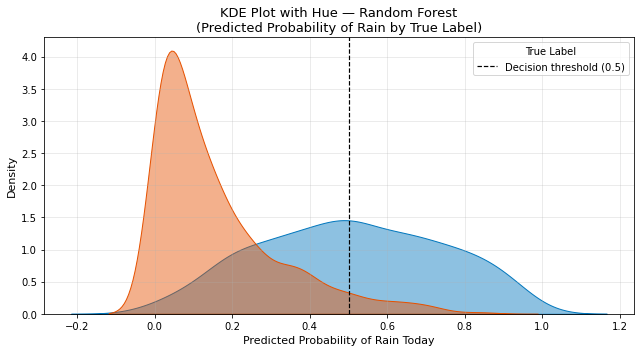

In [39]:
fig, ax = plt.subplots(figsize=(9, 5))

# Predicted probabilities for each test sample
proba_rf = pipeline_rf.predict_proba(X_test)[:, 1]

# Build a small frame pairing probability with the true label
kde_df_rf = pd.DataFrame({'Predicted Probability (Rain=Yes)': proba_rf,
                          'True Label': y_test.values})

sns.kdeplot(data=kde_df_rf, x='Predicted Probability (Rain=Yes)',
            hue='True Label', fill=True, common_norm=False,
            palette={'Yes': '#0277bd', 'No': '#e65100'}, alpha=0.45, ax=ax)

ax.axvline(0.5, color='black', linestyle='--', linewidth=1.2, label='Decision threshold (0.5)')
ax.set_title('KDE Plot with Hue — Random Forest\n(Predicted Probability of Rain by True Label)',
             fontsize=13)
ax.set_xlabel('Predicted Probability of Rain Today', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.legend(title='True Label', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**KDE Plot with Hue: All Three Models (Random Forest | Logistic Regression | Decision Tree)**

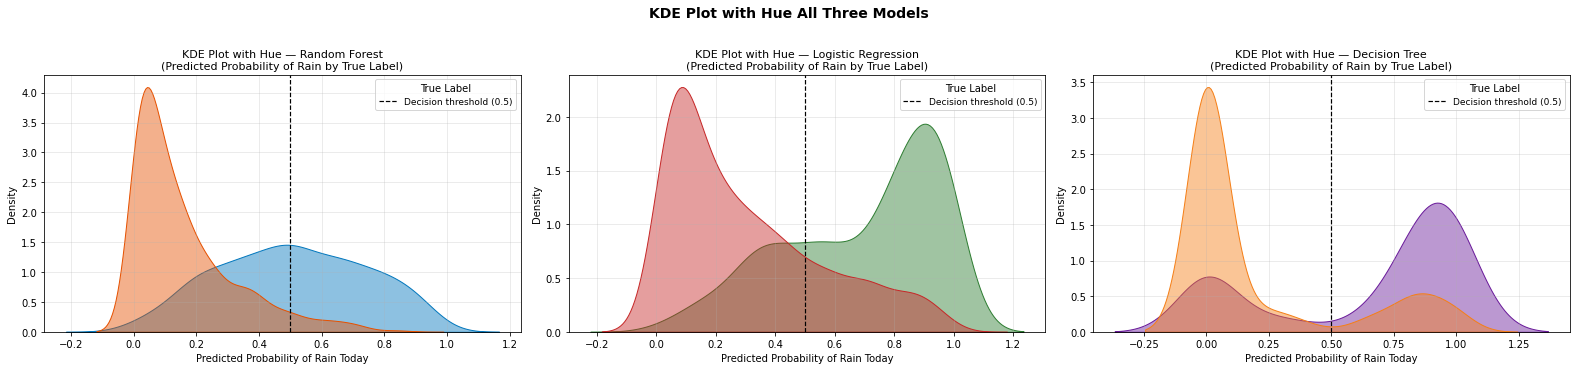

In [41]:
# KDE Plot with Hue: All Three Models (Random Forest | Logistic Regression | Decision Tree)

# ── Predicted probabilities for all three models ──────────────────────────────
proba_rf = pipeline_rf.predict_proba(X_test)[:, 1]
proba_lr = pipeline_lr.predict_proba(X_test)[:, 1]
proba_dt = pipeline_dt.predict_proba(X_test)[:, 1]

models = [
    ('Random Forest',       proba_rf, {'Yes': '#0277bd', 'No': '#e65100'}),
    ('Logistic Regression', proba_lr, {'Yes': '#2e7d32', 'No': '#c62828'}),
    ('Decision Tree',       proba_dt, {'Yes': '#6a1b9a', 'No': '#f57f17'}),
]

fig, axes = plt.subplots(1, 3, figsize=(22, 5))

for ax, (model_name, proba, palette) in zip(axes, models):
    kde_df = pd.DataFrame({
        'Predicted Probability (Rain=Yes)': proba,
        'True Label': y_test.values
    })

    sns.kdeplot(data=kde_df, x='Predicted Probability (Rain=Yes)',
                hue='True Label', fill=True, common_norm=False,
                palette=palette, alpha=0.45, ax=ax)

    ax.axvline(0.5, color='black', linestyle='--', linewidth=1.2, label='Decision threshold (0.5)')
    ax.set_title(f'KDE Plot with Hue — {model_name}\n(Predicted Probability of Rain by True Label)',
                 fontsize=11)
    ax.set_xlabel('Predicted Probability of Rain Today', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.legend(title='True Label', fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('KDE Plot with Hue All Three Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**ACE Distribution Patterns: All Three Models (Random Forest | Logistic Regression | Decision Tree)**

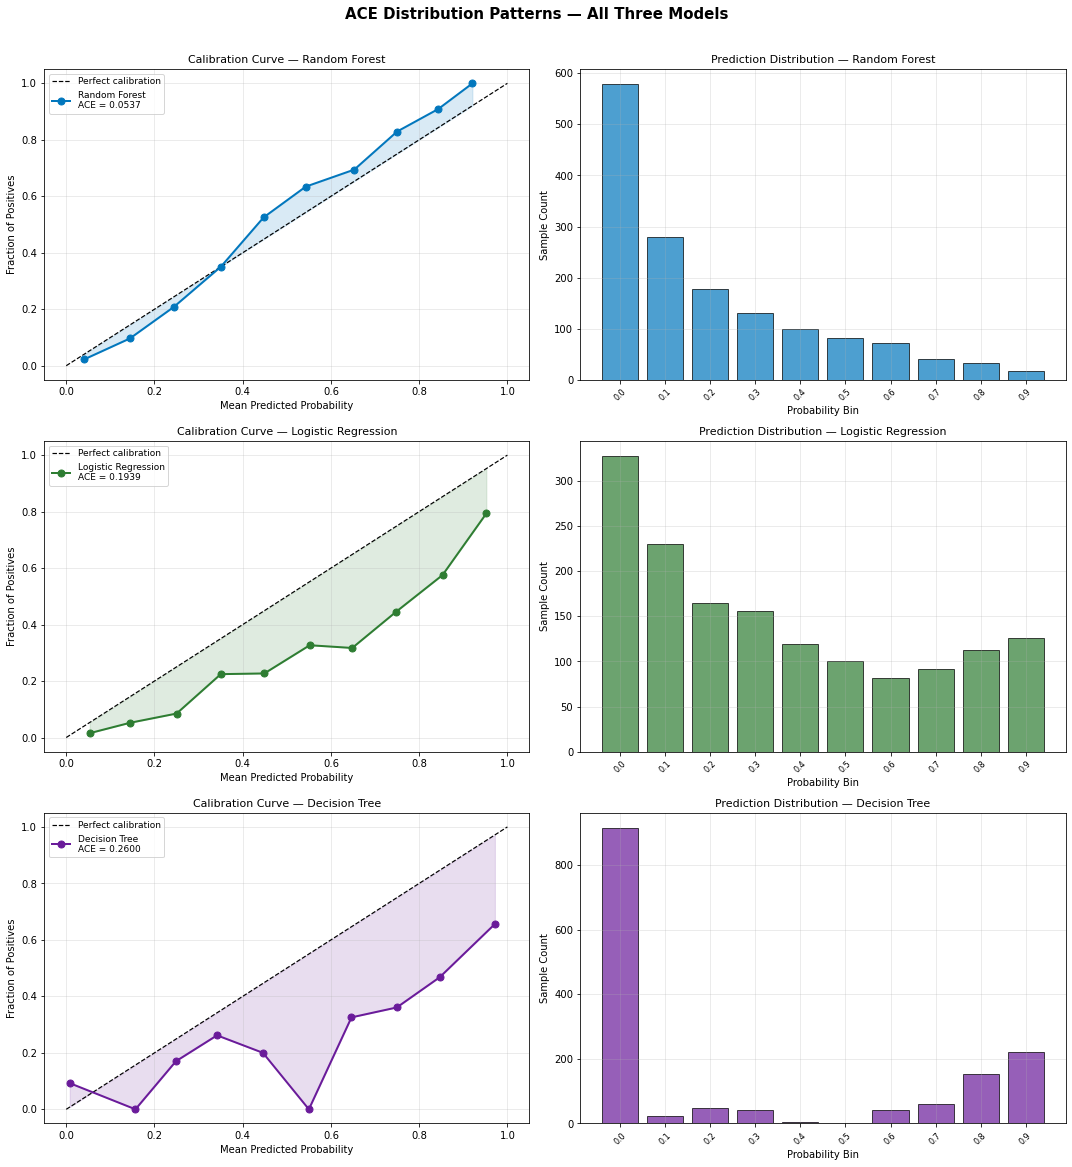

In [42]:
# ACE Distribution Patterns: All Three Models (Random Forest | Logistic Regression | Decision Tree)

# ── Reusable ACE plotter ───────────────────────────────────────────────────────
def plot_ace(proba, y_true, model_name, color, ax_cal, ax_hist):
    y_enc = (y_true == 'Yes').astype(int).values
    n_bins = 10
    bins = np.linspace(0, 1, n_bins + 1)
    bin_idx = np.clip(np.digitize(proba, bins) - 1, 0, n_bins - 1)

    mean_pred, mean_true, counts = [], [], []
    for b in range(n_bins):
        mask = bin_idx == b
        if mask.sum() > 0:
            mean_pred.append(proba[mask].mean())
            mean_true.append(y_enc[mask].mean())
            counts.append(mask.sum())
        else:
            mean_pred.append((bins[b] + bins[b+1]) / 2)
            mean_true.append(0)
            counts.append(0)

    ace = np.mean(np.abs(np.array(mean_pred) - np.array(mean_true)))

    # Calibration curve
    ax_cal.plot([0,1],[0,1], 'k--', lw=1.2, label='Perfect calibration')
    ax_cal.plot(mean_pred, mean_true, 'o-', color=color, lw=2, markersize=7,
                label=f'{model_name}\nACE = {ace:.4f}')
    ax_cal.fill_between(mean_pred, mean_pred, mean_true, alpha=0.15, color=color)
    ax_cal.set_xlabel('Mean Predicted Probability', fontsize=10)
    ax_cal.set_ylabel('Fraction of Positives', fontsize=10)
    ax_cal.set_title(f'Calibration Curve — {model_name}', fontsize=11)
    ax_cal.legend(fontsize=9)
    ax_cal.grid(alpha=0.3)

    # Distribution histogram
    ax_hist.bar(range(n_bins), counts, color=color, alpha=0.7, edgecolor='black', width=0.8)
    ax_hist.set_xlabel('Probability Bin', fontsize=10)
    ax_hist.set_ylabel('Sample Count', fontsize=10)
    ax_hist.set_title(f'Prediction Distribution — {model_name}', fontsize=11)
    ax_hist.set_xticks(range(n_bins))
    ax_hist.set_xticklabels([f'{bins[i]:.1f}' for i in range(n_bins)], rotation=45, fontsize=8)
    ax_hist.grid(alpha=0.3)

# ── Model definitions ─────────────────────────────────────────────────────────
models = [
    ('Random Forest',       proba_rf, '#0277bd'),
    ('Logistic Regression', proba_lr, '#2e7d32'),
    ('Decision Tree',       proba_dt, '#6a1b9a'),
]

fig, axes = plt.subplots(3, 2, figsize=(15, 16))

for row, (model_name, proba, color) in zip(axes, models):
    plot_ace(proba, y_test, model_name, color, row[0], row[1])

plt.suptitle('ACE Distribution Patterns — All Three Models', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Ridge Regression Diagnostic: All Three Models (Random Forest | Logistic Regression | Decision Tree)**

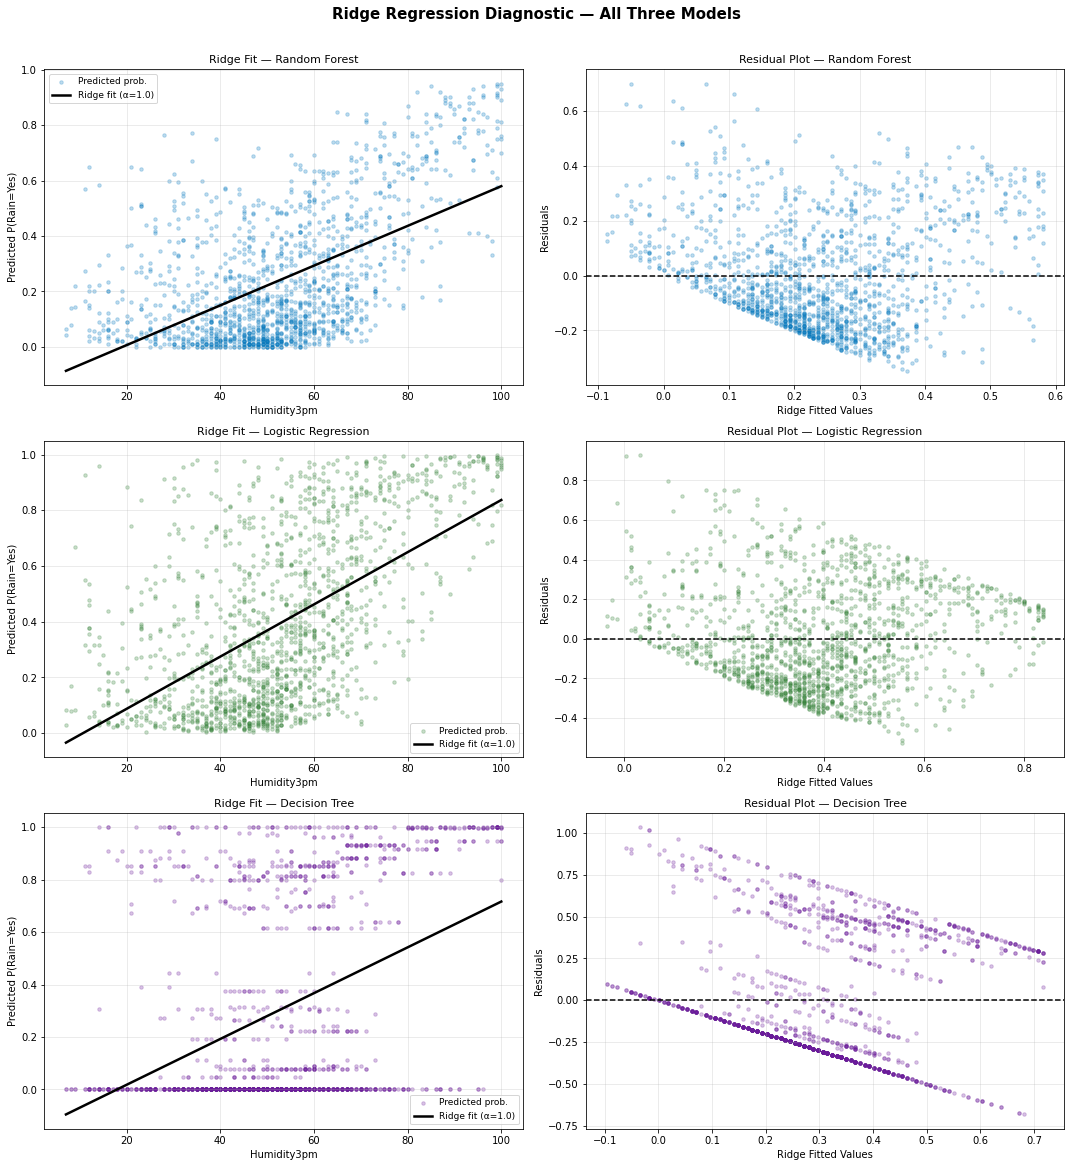

In [43]:
# Ridge Regression Diagnostic: All Three Models (Random Forest | Logistic Regression | Decision Tree)

from sklearn.linear_model import Ridge

# ── Reusable Ridge diagnostic plotter ────────────────────────────────────────
def plot_ridge_diagnostic(proba, X_test_df, model_name, color, ax_fit, ax_res, feature='Humidity3pm'):
    x = X_test_df[feature].values.reshape(-1, 1)

    ridge = Ridge(alpha=1.0)
    ridge.fit(x, proba)
    x_line = np.linspace(x.min(), x.max(), 300).reshape(-1, 1)
    y_line = ridge.predict(x_line)
    residuals = proba - ridge.predict(x)

    # Scatter + Ridge fit
    ax_fit.scatter(x, proba, alpha=0.25, s=12, color=color, label='Predicted prob.')
    ax_fit.plot(x_line, y_line, color='black', lw=2.5, label='Ridge fit (α=1.0)')
    ax_fit.set_xlabel(feature, fontsize=10)
    ax_fit.set_ylabel('Predicted P(Rain=Yes)', fontsize=10)
    ax_fit.set_title(f'Ridge Fit — {model_name}', fontsize=11)
    ax_fit.legend(fontsize=9)
    ax_fit.grid(alpha=0.3)

    # Residuals
    ax_res.scatter(ridge.predict(x), residuals, alpha=0.25, s=12, color=color)
    ax_res.axhline(0, color='black', lw=1.5, linestyle='--')
    ax_res.set_xlabel('Ridge Fitted Values', fontsize=10)
    ax_res.set_ylabel('Residuals', fontsize=10)
    ax_res.set_title(f'Residual Plot — {model_name}', fontsize=11)
    ax_res.grid(alpha=0.3)

# ── Model definitions ─────────────────────────────────────────────────────────
models = [
    ('Random Forest',       proba_rf, '#0277bd'),
    ('Logistic Regression', proba_lr, '#2e7d32'),
    ('Decision Tree',       proba_dt, '#6a1b9a'),
]

X_test_reset = X_test.reset_index(drop=True)

fig, axes = plt.subplots(3, 2, figsize=(15, 16))

for row, (model_name, proba, color) in zip(axes, models):
    plot_ridge_diagnostic(proba, X_test_reset, model_name, color, row[0], row[1])

plt.suptitle('Ridge Regression Diagnostic — All Three Models', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Bayesian Posterior Distribution: All Three Models (Random Forest | Logistic Regression | Decision Tree)**

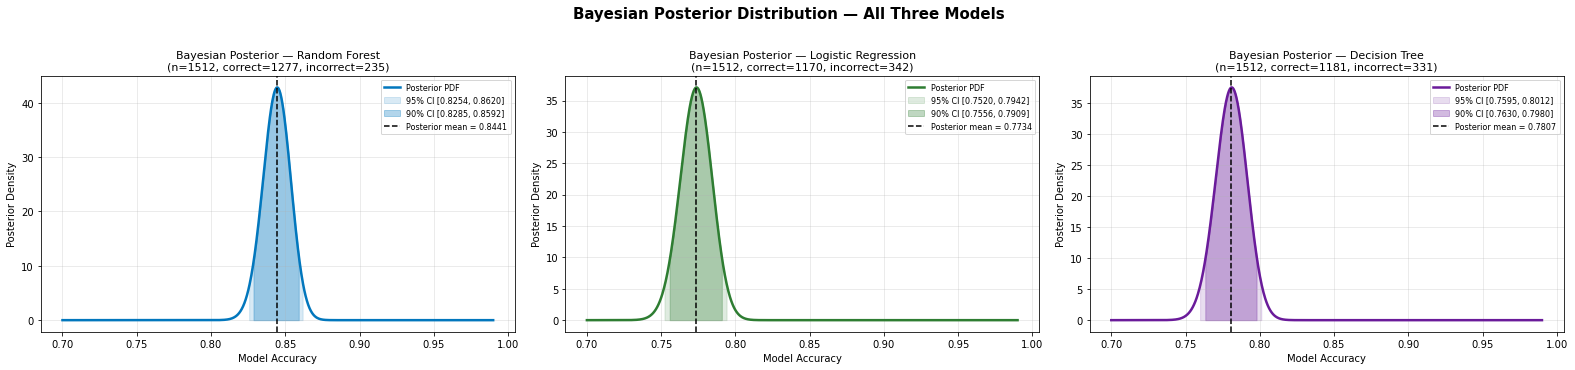

In [44]:
# Bayesian Posterior Distribution: All Three Models (Random Forest | Logistic Regression | Decision Tree)

from scipy.stats import beta as beta_dist

# ── Reusable Bayesian posterior plotter ───────────────────────────────────────
def plot_bayesian_posterior(y_true, y_pred_model, model_name, color, ax):
    correct   = (y_true == y_pred_model).sum()
    incorrect = len(y_true) - correct
    total     = len(y_true)

    # Prior: Beta(1,1) — uniform, no prior knowledge
    # Posterior: Beta(1 + correct, 1 + incorrect)
    alpha_post = 1 + correct
    beta_post  = 1 + incorrect

    x   = np.linspace(0.70, 0.99, 1000)
    pdf = beta_dist.pdf(x, alpha_post, beta_post)

    posterior_mean = alpha_post / (alpha_post + beta_post)
    ci_90 = beta_dist.interval(0.90, alpha_post, beta_post)
    ci_95 = beta_dist.interval(0.95, alpha_post, beta_post)

    ax.plot(x, pdf, color=color, lw=2.5, label='Posterior PDF')
    ax.fill_between(x, pdf,
                    where=((x >= ci_95[0]) & (x <= ci_95[1])),
                    alpha=0.15, color=color,
                    label=f'95% CI [{ci_95[0]:.4f}, {ci_95[1]:.4f}]')
    ax.fill_between(x, pdf,
                    where=((x >= ci_90[0]) & (x <= ci_90[1])),
                    alpha=0.30, color=color,
                    label=f'90% CI [{ci_90[0]:.4f}, {ci_90[1]:.4f}]')
    ax.axvline(posterior_mean, color='black', linestyle='--', lw=1.5,
               label=f'Posterior mean = {posterior_mean:.4f}')
    ax.set_xlabel('Model Accuracy', fontsize=10)
    ax.set_ylabel('Posterior Density', fontsize=10)
    ax.set_title(f'Bayesian Posterior — {model_name}\n'
                 f'(n={total}, correct={correct}, incorrect={incorrect})', fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

# ── Model definitions ─────────────────────────────────────────────────────────
y_pred_rf_final  = pipeline_rf.predict(X_test)
y_pred_lr_final  = pipeline_lr.predict(X_test)
y_pred_dt_final  = pipeline_dt.predict(X_test)

models = [
    ('Random Forest',       y_pred_rf_final,  '#0277bd'),
    ('Logistic Regression', y_pred_lr_final,  '#2e7d32'),
    ('Decision Tree',       y_pred_dt_final,  '#6a1b9a'),
]

fig, axes = plt.subplots(1, 3, figsize=(22, 5))

for ax, (model_name, y_pred_model, color) in zip(axes, models):
    plot_bayesian_posterior(y_test, y_pred_model, model_name, color, ax)

plt.suptitle('Bayesian Posterior Distribution — All Three Models', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Precision-Recall Curve: All Three Models (Random Forest | Logistic Regression | Decision Tree)**

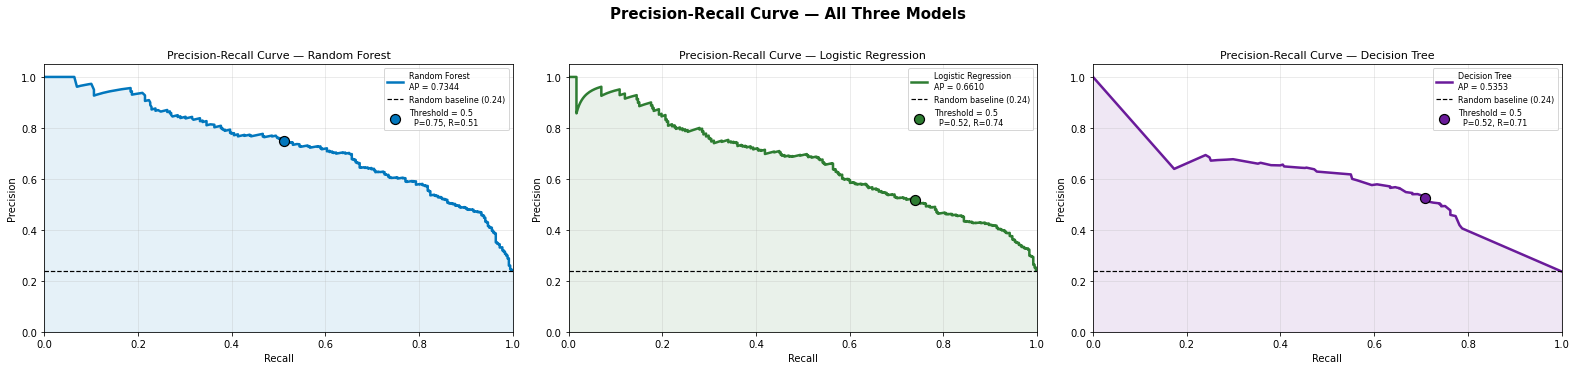

In [45]:
# Precision-Recall Curve: All Three Models (Random Forest | Logistic Regression | Decision Tree)

from sklearn.metrics import precision_recall_curve, average_precision_score

# ── Reusable Precision-Recall plotter ────────────────────────────────────────
def plot_precision_recall(proba, y_true, model_name, color, ax):
    y_enc = (y_true == 'Yes').astype(int).values

    precision, recall, thresholds = precision_recall_curve(y_enc, proba)
    avg_precision = average_precision_score(y_enc, proba)

    # Baseline — random classifier performance (fraction of positives)
    baseline = y_enc.mean()

    ax.plot(recall, precision, color=color, lw=2.5,
            label=f'{model_name}\nAP = {avg_precision:.4f}')
    ax.fill_between(recall, precision, alpha=0.10, color=color)
    ax.axhline(baseline, color='black', linestyle='--', lw=1.2,
               label=f'Random baseline ({baseline:.2f})')

    # Mark the point closest to threshold = 0.5
    closest_idx = np.argmin(np.abs(thresholds - 0.5))
    ax.scatter(recall[closest_idx], precision[closest_idx],
               color=color, s=100, zorder=5, edgecolors='black', linewidths=1.2,
               label=f'Threshold = 0.5\n  P={precision[closest_idx]:.2f}, R={recall[closest_idx]:.2f}')

    ax.set_xlabel('Recall', fontsize=10)
    ax.set_ylabel('Precision', fontsize=10)
    ax.set_title(f'Precision-Recall Curve — {model_name}', fontsize=11)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

# ── Model definitions ─────────────────────────────────────────────────────────
models = [
    ('Random Forest',       proba_rf, '#0277bd'),
    ('Logistic Regression', proba_lr, '#2e7d32'),
    ('Decision Tree',       proba_dt, '#6a1b9a'),
]

fig, axes = plt.subplots(1, 3, figsize=(22, 5))

for ax, (model_name, proba, color) in zip(axes, models):
    plot_precision_recall(proba, y_test, model_name, color, ax)

plt.suptitle('Precision-Recall Curve — All Three Models', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Learning Curve: All Three Models (Random Forest | Logistic Regression | Decision Tree)**

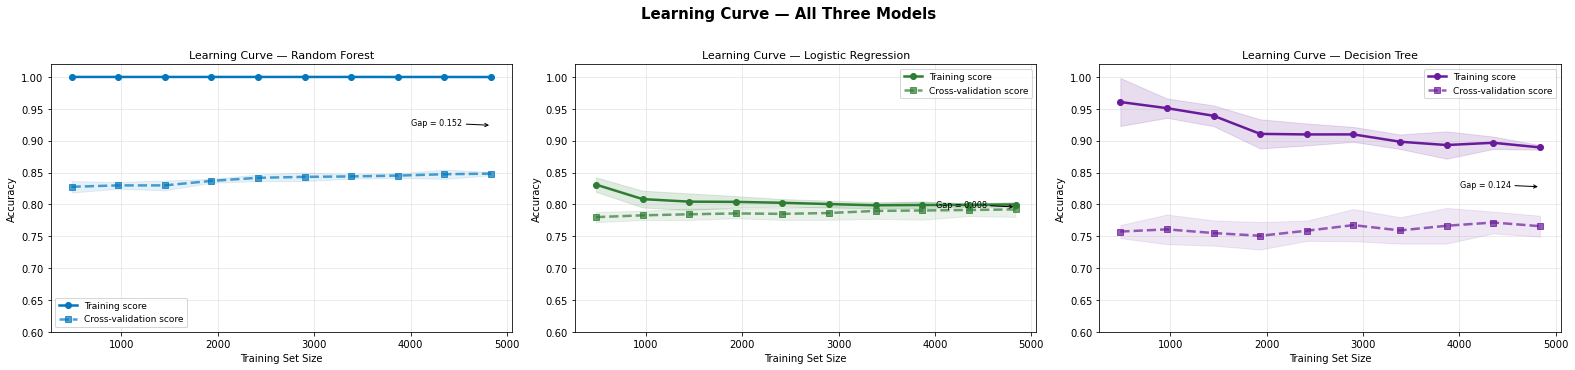

In [46]:
# Learning Curve: All Three Models (Random Forest | Logistic Regression | Decision Tree)

from sklearn.model_selection import learning_curve

# ── Reusable Learning Curve plotter ──────────────────────────────────────────
def plot_learning_curve(pipeline_model, X_train_data, y_train_data, model_name, color, ax):
    train_sizes, train_scores, val_scores = learning_curve(
        pipeline_model,
        X_train_data, y_train_data,
        cv=5,
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy',
        shuffle=True,
        random_state=42
    )

    # Mean and standard deviation across CV folds
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    # Training score line
    ax.plot(train_sizes, train_mean, 'o-', color=color, lw=2.5, label='Training score')
    ax.fill_between(train_sizes,
                    train_mean - train_std,
                    train_mean + train_std,
                    alpha=0.15, color=color)

    # Validation score line
    ax.plot(train_sizes, val_mean, 's--', color=color, lw=2.5,
            alpha=0.7, label='Cross-validation score')
    ax.fill_between(train_sizes,
                    val_mean - val_std,
                    val_mean + val_std,
                    alpha=0.10, color=color)

    # Gap annotation at the largest training size
    gap = train_mean[-1] - val_mean[-1]
    ax.annotate(f'Gap = {gap:.3f}',
                xy=(train_sizes[-1], (train_mean[-1] + val_mean[-1]) / 2),
                xytext=(-80, 0), textcoords='offset points',
                fontsize=8, color='black',
                arrowprops=dict(arrowstyle='->', color='black', lw=1.0))

    ax.set_xlabel('Training Set Size', fontsize=10)
    ax.set_ylabel('Accuracy', fontsize=10)
    ax.set_title(f'Learning Curve — {model_name}', fontsize=11)
    ax.set_ylim([0.60, 1.02])
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

# ── Model definitions ─────────────────────────────────────────────────────────
models = [
    ('Random Forest',       pipeline_rf, '#0277bd'),
    ('Logistic Regression', pipeline_lr, '#2e7d32'),
    ('Decision Tree',       pipeline_dt, '#6a1b9a'),
]

fig, axes = plt.subplots(1, 3, figsize=(22, 5))

for ax, (model_name, pipeline_model, color) in zip(axes, models):
    plot_learning_curve(pipeline_model, X_train, y_train, model_name, color, ax)

plt.suptitle('Learning Curve — All Three Models', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**Radar Chart: All Three Models (Random Forest | Logistic Regression | Decision Tree)**

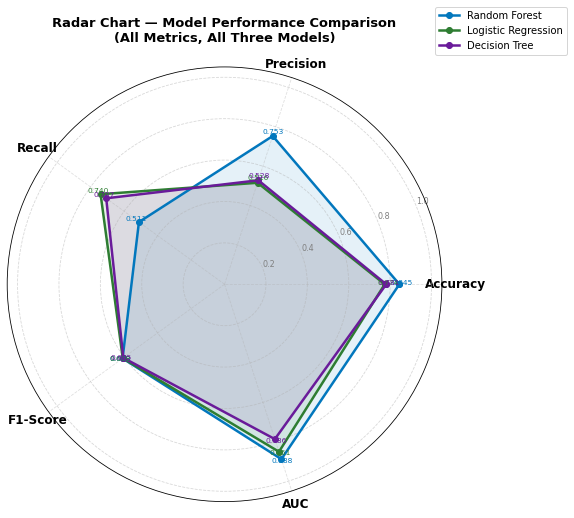

In [47]:
# Radar Chart: All Three Models (Random Forest | Logistic Regression | Decision Tree)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score
import matplotlib.patches as mpatches

# ── Compute metrics for all three models ──────────────────────────────────────
y_pred_rf_final = pipeline_rf.predict(X_test)
y_pred_lr_final = pipeline_lr.predict(X_test)
y_pred_dt_final = pipeline_dt.predict(X_test)

y_test_enc = (y_test == 'Yes').astype(int)

def get_metrics(y_true, y_pred, y_proba):
    return [
        round(accuracy_score(y_true, y_pred),                              4),
        round(precision_score(y_true, y_pred, pos_label='Yes'),            4),
        round(recall_score(y_true, y_pred, pos_label='Yes'),               4),
        round(f1_score(y_true, y_pred, pos_label='Yes'),                   4),
        round(roc_auc_score((y_true == 'Yes').astype(int), y_proba),       4),
    ]

metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']

models = [
    ('Random Forest',       y_pred_rf_final, proba_rf, '#0277bd'),
    ('Logistic Regression', y_pred_lr_final, proba_lr, '#2e7d32'),
    ('Decision Tree',       y_pred_dt_final, proba_dt, '#6a1b9a'),
]

# ── Radar chart setup ─────────────────────────────────────────────────────────
num_metrics = len(metric_labels)

# Angles for each metric — evenly spaced, closed loop
angles = np.linspace(0, 2 * np.pi, num_metrics, endpoint=False).tolist()
angles += angles[:1]                          # close the polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for model_name, y_pred_model, proba, color in models:
    values = get_metrics(y_test, y_pred_model, proba)
    values += values[:1]                      # close the polygon

    ax.plot(angles, values, 'o-', color=color, lw=2.5, label=model_name)
    ax.fill(angles, values, color=color, alpha=0.10)

    # Annotate each vertex with its value
    for angle, value in zip(angles[:-1], values[:-1]):
        ax.annotate(f'{value:.3f}',
                    xy=(angle, value),
                    xytext=(angle, value + 0.015),
                    fontsize=7.5,
                    ha='center', color=color)

# ── Axis labels and styling ───────────────────────────────────────────────────
ax.set_xticks(angles[:-1])
ax.set_xticklabels(metric_labels, fontsize=12, fontweight='bold')
ax.set_ylim(0.0, 1.05)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=8, color='grey')
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.xaxis.grid(True, linestyle='--', alpha=0.4)

ax.set_title('Radar Chart — Model Performance Comparison\n(All Metrics, All Three Models)',
             fontsize=13, fontweight='bold', pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.30, 1.15), fontsize=10)

plt.tight_layout()
plt.show()